<a href="https://colab.research.google.com/github/Hardrach/intelligent-banking-fraud-detection/blob/main/Projet_Data%26AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Intelligent Banking Fraud Detection System Using Data Science and Deep Learning***

---

# ***Étape 1 — Importer les bibliothèques***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ***Étape 2 — Importer le dataset***

In [2]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# ***Étape 3 — Comprendre les données***

In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180351 entries, 0 to 180350
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    180351 non-null  float64
 1   V1      180351 non-null  float64
 2   V2      180351 non-null  float64
 3   V3      180351 non-null  float64
 4   V4      180351 non-null  float64
 5   V5      180351 non-null  float64
 6   V6      180351 non-null  float64
 7   V7      180351 non-null  float64
 8   V8      180351 non-null  float64
 9   V9      180350 non-null  float64
 10  V10     180350 non-null  float64
 11  V11     180350 non-null  float64
 12  V12     180350 non-null  float64
 13  V13     180350 non-null  float64
 14  V14     180350 non-null  float64
 15  V15     180350 non-null  float64
 16  V16     180350 non-null  float64
 17  V17     180350 non-null  float64
 18  V18     180350 non-null  float64
 19  V19     180350 non-null  float64
 20  V20     180350 non-null  float64
 21  V21     18

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,1


# ***Étape 4 — Data Cleaning***

In [4]:
df.duplicated().sum()
df = df.drop_duplicates()

In [5]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,1


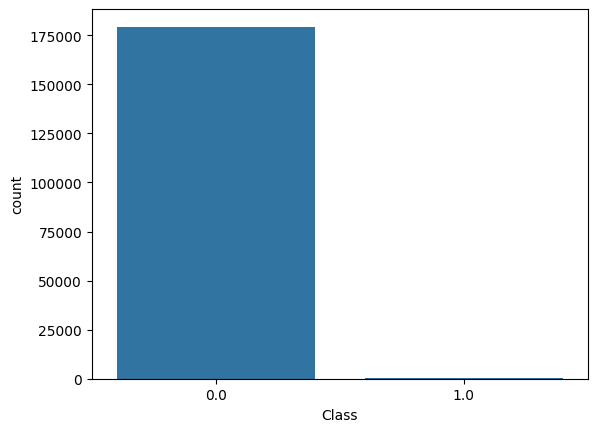

In [6]:
sns.countplot(x='Class', data=df)
plt.show()

# ***Étape 5 — EDA + Visualisation***

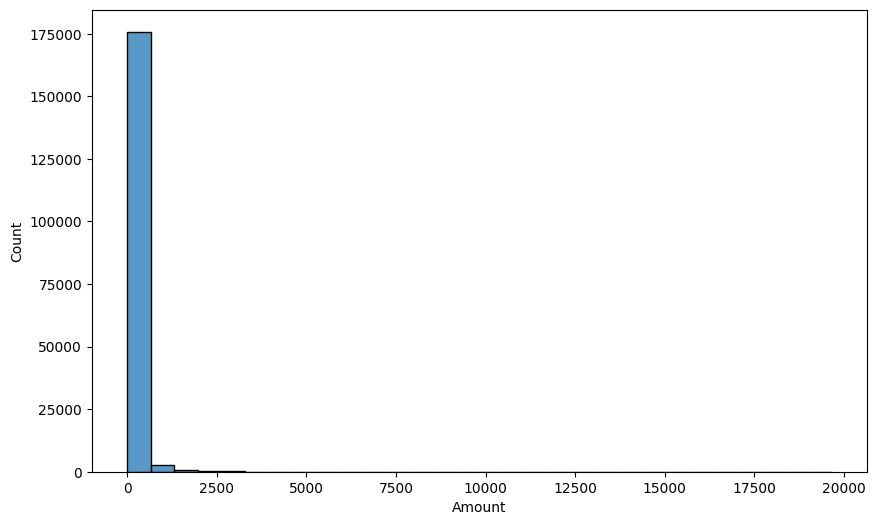

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['Amount'], bins=30)
plt.show()

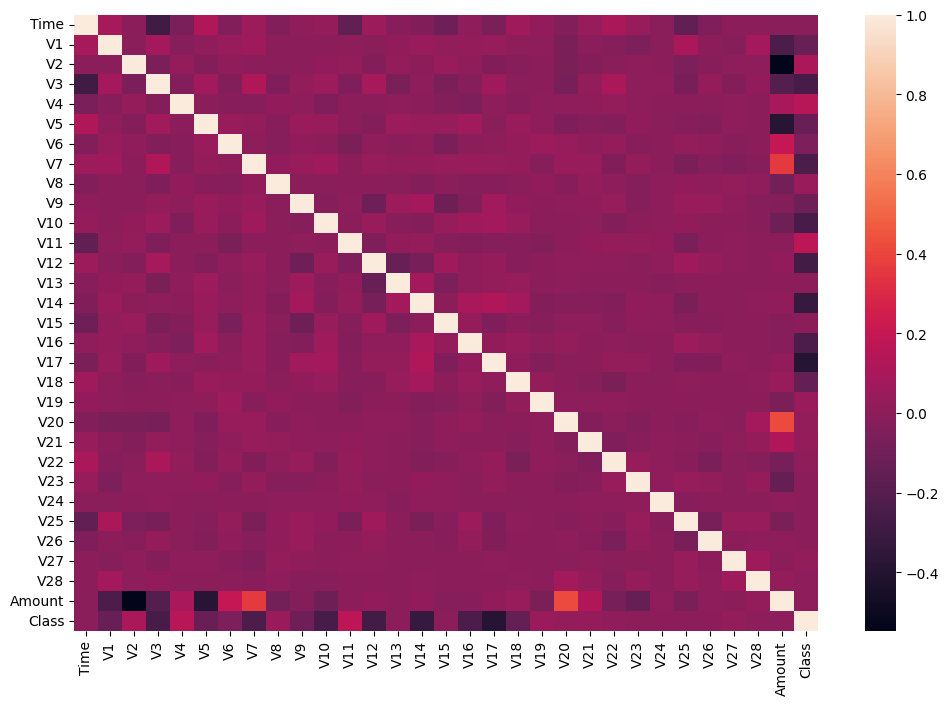

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr())
plt.show()

# ***Étape 6 — Préparation des données***

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ***Étape 7 — Création du modèle ANN***

In [13]:
model = Sequential()

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ***Étape 8 — Entraînement***

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9965 - loss: 0.0160 - val_accuracy: 0.9990 - val_loss: 0.0051
Epoch 2/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9990 - val_loss: 0.0049
Epoch 3/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9990 - val_loss: 0.0048
Epoch 4/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 5/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0042
Epoch 6/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9992 - val_loss: 0.0056
Epoch 7/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 8/10
3594/3594 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9995 - loss: 0.0017

# ***Étape 9 — Prediction***

In [24]:
pred = model.predict(X_test)
pred = (pred > 0.5).astype(int).flatten()

1123/1123 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


# ***Étape 10 — Évaluation***

In [25]:
nan_indices = y_test.isna()
y_test_cleaned = y_test[~nan_indices]
pred_cleaned = pred[~nan_indices]

print(classification_report(y_test_cleaned, pred_cleaned))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     35862
         1.0       0.88      0.81      0.84        73

    accuracy                           1.00     35935
   macro avg       0.94      0.90      0.92     35935
weighted avg       1.00      1.00      1.00     35935



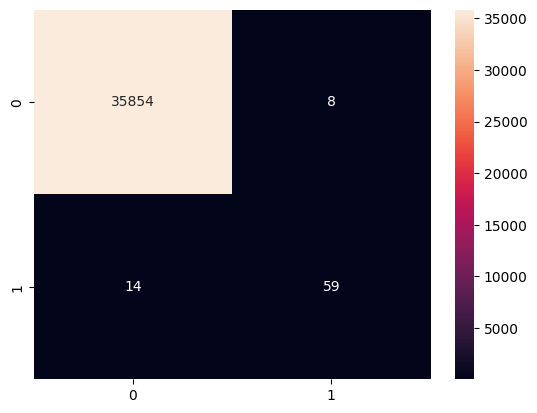

In [26]:
cm = confusion_matrix(y_test_cleaned, pred_cleaned)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [27]:
print(accuracy_score(y_test_cleaned, pred_cleaned))

0.9993877834979825


In [28]:
print(y_test.isnull().sum())

1


# ***Étape 11 — Decision***

In [29]:
def fraud_decision(score):
    if score < 0.3:
        return "Transaction Approved"

    elif score < 0.7:
        return "Customer Verification Required"

    else:
        return "Transaction Blocked - Fraud Alert"


example_score = 0.92

print("Fraud Score:", example_score)
print("Decision:", fraud_decision(example_score))

Fraud Score: 0.92
Decision: Transaction Blocked - Fraud Alert


**Graphique Accuracy / Loss**

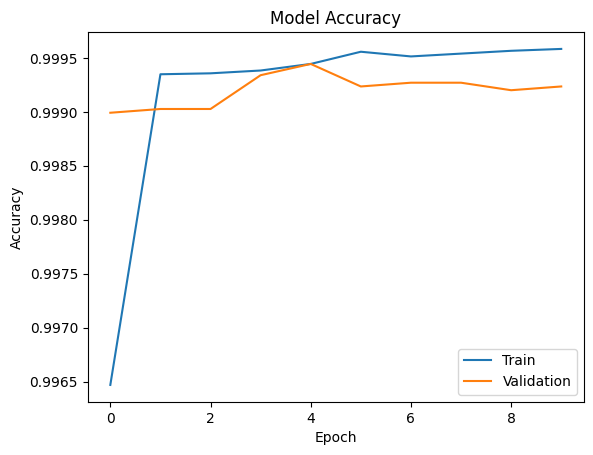

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

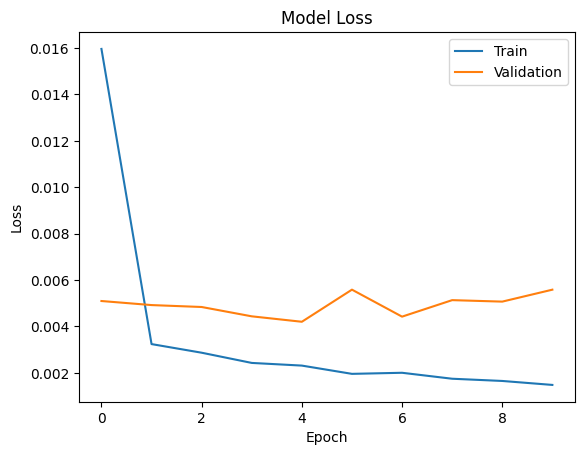

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()